## **MID TERM EXAMINATION**

---

**Name:** **Mohammad Tuhin**

**Email: md.tuhin42525@gmail.com**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, SGDRegressor, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

## **Question 1: Exploratory Data Analysis (EDA)**

In [4]:
df = pd.read_csv("adult_income.csv")

df.sample(3)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
40075,63,Private,697806,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,60,United-States,<=50K.
16361,24,Private,210781,Bachelors,13,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,France,<=50K
25934,47,Private,503454,12th,8,Never-married,Adm-clerical,Other-relative,Black,Female,0,0,40,United-States,<=50K


In [5]:
print("Shape: ",df.shape)
print("Info: ", df.info())

Shape:  (48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
Info:  None


In [6]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [8]:
(df == ' ?').sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

In [9]:
df.replace(' ?', np.nan, inplace=True)

In [10]:
print("Initial duplicate count: ", df.duplicated().sum())

df.drop_duplicates(inplace=True)
print("Duplicate count after removal: ", df.duplicated().sum())

Initial duplicate count:  29
Duplicate count after removal:  0


In [11]:
df['income'].unique()
df['income'] = df["income"].str.replace('.', '', regex=False)

In [12]:
print("Incom Distribution: ")
df['income'].value_counts()

Incom Distribution: 


income
<=50K    37128
>50K     11685
Name: count, dtype: int64

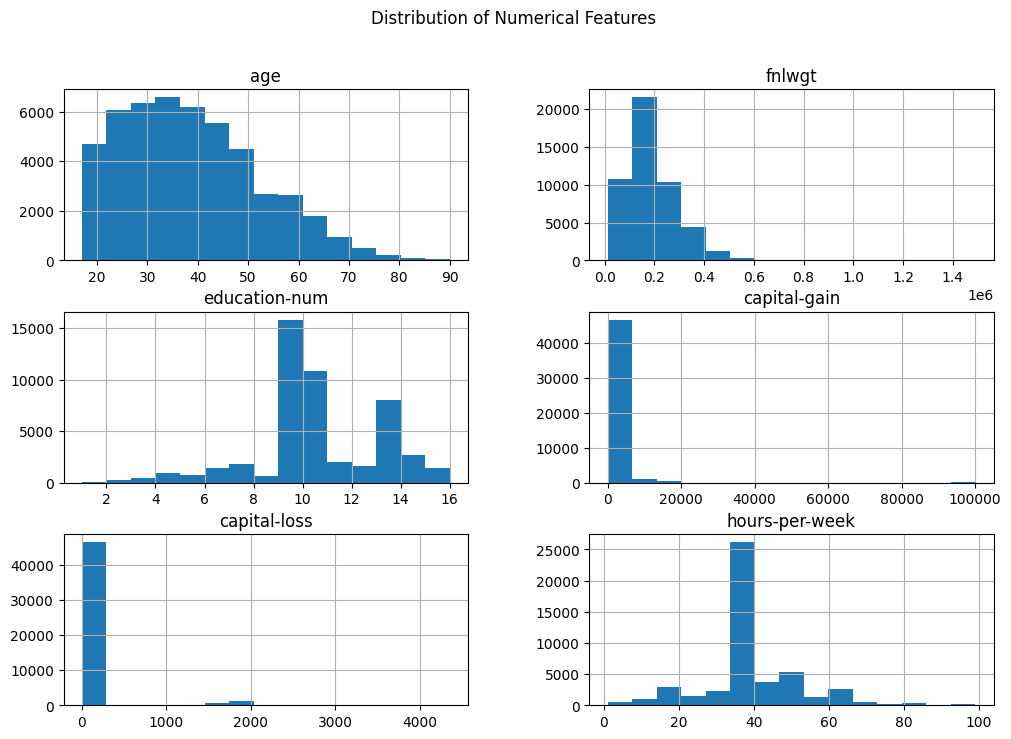

In [13]:
df.hist(bins=15, figsize=(12, 8))

plt.suptitle("Distribution of Numerical Features")
plt.show()

In [14]:
(df['income'].value_counts() / len(df)) * 100

income
<=50K    76.061705
>50K     23.938295
Name: count, dtype: float64

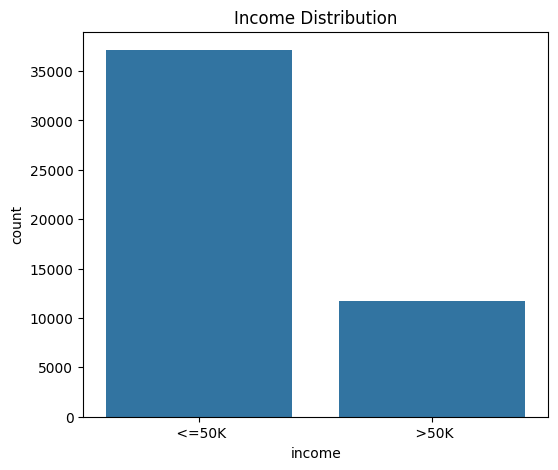

In [15]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='income')
plt.title("Income Distribution")
plt.show()

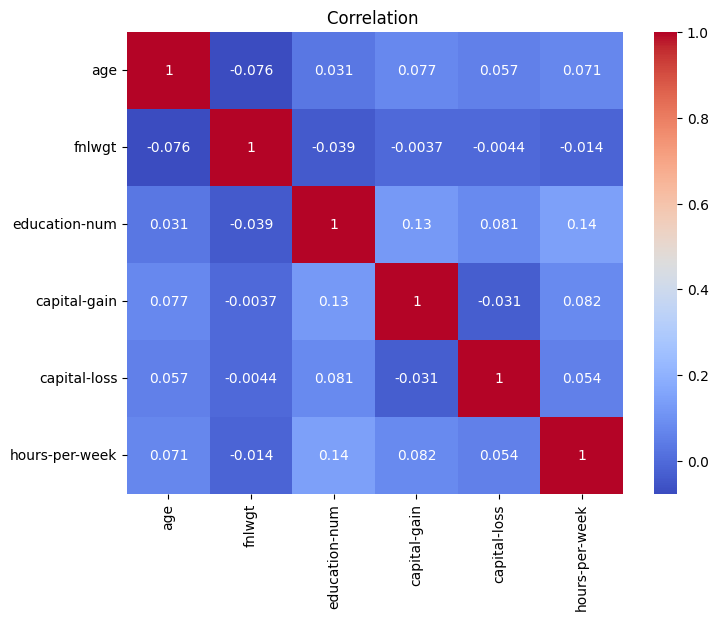

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation ")
plt.show()

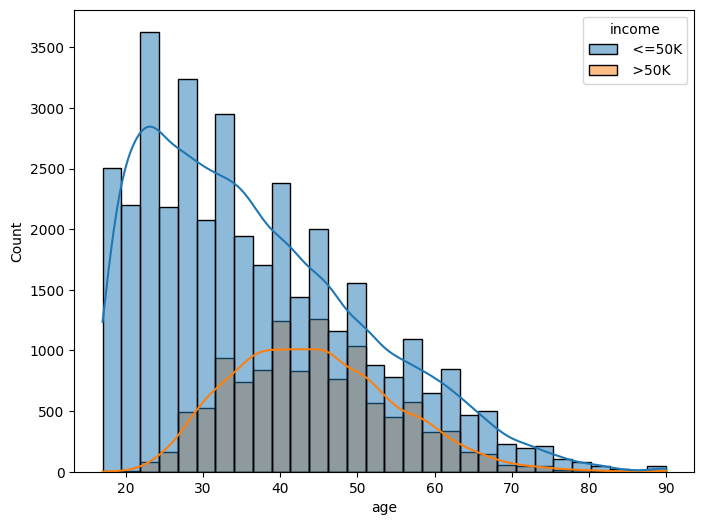

In [17]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x = 'age', hue='income', bins=30, kde=True)
plt.show()

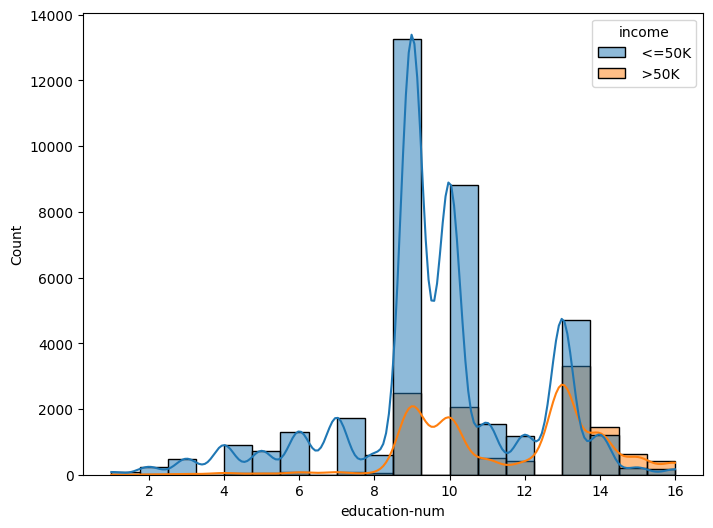

In [18]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x = 'education-num', hue='income', bins=20, kde=True)
plt.show()

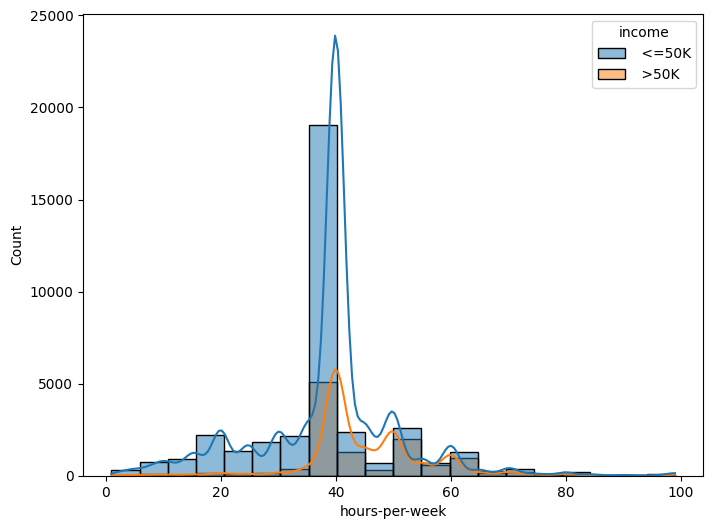

In [19]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x = 'hours-per-week', hue='income', bins=20, kde=True)
plt.show()

In [20]:
df['income'] = (df['income'].str.strip().str.replace('-', '', regex=False))

In [21]:
# statistical evidence

df['income_binary'] = (
    df['income'] == '>50K'
).astype(int)

feature = ['age', 'education-num', 'hours-per-week']

for col in feature:
  print(f"\n{col}")
  print("-"*30)
  print("Mean by Income")
  print(df.groupby('income')[col].mean().round(2))

  print("Correlation: ", round(df[col].corr(df['income_binary']), 3))


age
------------------------------
Mean by Income
income
<=50K    36.88
>50K     44.28
Name: age, dtype: float64
Correlation:  0.23

education-num
------------------------------
Mean by Income
income
<=50K     9.6
>50K     11.6
Name: education-num, dtype: float64
Correlation:  0.333

hours-per-week
------------------------------
Mean by Income
income
<=50K    38.84
>50K     45.45
Name: hours-per-week, dtype: float64
Correlation:  0.228


## **intuitively affects income**

---



**Education-num:** People with more education often qualify for the better-paying jobs, so their tends to be higher.

**Age:** Older individuals often have more experience and therefore earn higher salaries.

**Hours-per-week:** People who work more hours generally have greater responsibities and receive higher compensation.

---



## **3 features from most important to least important**

---

The top three factors are Education-Num, Age and Hours-per-week. Education-Num is the most important due to its strong impact on skills and job opportunities. Age comes second because experience increase earning potential and Hours-per-week comes third since longer working hours may lead to higher income but are not the sole determinant of earnings.

## **Question 2: Preprocessing Pipeline Design (Regression)**

In [22]:
X = df.drop(['hours-per-week'], axis=1)
y = df['hours-per-week']

In [23]:
# numerical features
numerical_features = X.select_dtypes(
    include=['float64', 'int64']
).columns.tolist()

# categorical features
categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()


In [24]:
from sklearn import preprocessing
# numerical
numerical_pipeline = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
# numerical_pipeline

# categorical
categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)
# feature_pipeline


# columnTransform
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_pipeline, numerical_features),
        ('categorical', categorical_pipeline, categorical_features)
    ]
)
preprocessor

,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [25]:
X_preprocessed = preprocessor.fit_transform(X)

print("Preprocessor Shape: ", X_preprocessed.shape)

Preprocessor Shape:  (48813, 107)


**For Numerical Features preprocessing applied:**

Missing values -> SimpleImputer(Strategy='Median')

Scaling -> StandardScaler()

**Why?**

=>Median is robust to outliers.

=>StandardScaler normalizes feature scales, helping regression algorithms perform better.


**For Categorical Features Preprocessing applied:**

Missing values -> SimpleImputer(strategy='most_frequent')

Encoding -> OneHotEncoder(handle_unknown-'ignore')

**why?**

=> Most frequent imputation preserves the most common category.

=> Regression models cannot work directly with text data, so OneHot Encoding converts categories into numerical binary features.

=> handle_unknown='ignore' prevents errors when new categories appear in test data.

## **Question 3: Regression Modeling & Evaluation**

In [26]:
# X, y define Question 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [27]:
X_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,native-country,income,income_binary
40819,70,NaN,210722,Prof-school,15,Divorced,NaN,Not-in-family,White,Male,2538,0,United-States,<=50K,0
40613,30,Private,195602,12th,8,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,United-States,<=50K,0
45445,59,Private,171242,Bachelors,13,Separated,Exec-managerial,Not-in-family,White,Male,0,0,United-States,<=50K,0
31318,22,Private,138504,Some-college,10,Never-married,Adm-clerical,Unmarried,Black,Female,0,0,United-States,<=50K,0
3719,21,Local-gov,596776,Some-college,10,Never-married,Adm-clerical,Own-child,White,Male,0,0,Guatemala,<=50K,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11287,24,State-gov,247075,HS-grad,9,Never-married,Adm-clerical,Unmarried,Black,Female,0,0,United-States,<=50K,0
44759,52,Private,279440,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,United-States,>50K,1
38183,51,Self-emp-inc,77392,10th,6,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,United-States,>50K,1
860,18,Private,216284,11th,7,Never-married,Adm-clerical,Own-child,White,Female,0,0,United-States,<=50K,0


In [28]:
# Linear Regression Pipeline

lr_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
lr_pred = lr_pipeline.predict(X_test)

In [30]:
# SGD Regressor
sgd_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', SGDRegressor())
    ]
)

sgd_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
sgd_pred = sgd_pipeline.predict(X_test)

In [32]:
# Linear Reg
print("For Linear Regression")
print(f"R2: {round(r2_score(y_test, lr_pred), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, lr_pred), 4)}")
print(f"MSE: {round(mean_squared_error(y_test, lr_pred), 4)}")

print('-'*30)
# SGD Reg
print("For (SGD) Regressor")
print(f"R2: {round(r2_score(y_test, sgd_pred), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, sgd_pred), 4)}")
print(f"MSE: {round(mean_squared_error(y_test, sgd_pred), 4)}")

For Linear Regression
R2: 0.1833
MAE: 7.7534
MSE: 124.7332
------------------------------
For (SGD) Regressor
R2: 0.1806
MAE: 7.76
MSE: 125.1402


Linear Regression performed slightly better than the SGD Regressor because it achieved a marginally higher R2 score and lower MAE and MSE values. However, the difference are vary small, indicating that both models performed almost equally on this dataset

## **Question 4: Classification Pipeline & Error Analysis**

In [33]:
X = df.drop(['income'], axis=1)
y = df['income']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 42, stratify=y)

In [35]:
# numerical_features

num_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# categorical_features
cat_features = X.select_dtypes(
    include=['object']
).columns.tolist()

In [36]:
num_pipeline = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [37]:
cat_pipeline = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [38]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)

In [39]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [40]:
logistic_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(class_weight='balanced' ,max_iter=1000, random_state=42))
    ]
)

In [41]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
y_pred = logistic_pipeline.predict(X_test)

In [43]:
print(f"Accuracy: {round(accuracy_score(y_test, y_pred), 4)}")
print(f"Precision: {round(precision_score(y_test, y_pred, pos_label='>50K'), 4)}")
print(f"Recall: {round(recall_score(y_test, y_pred, pos_label='>50K'), 4)}")

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


In [44]:
lr_accuracy = round(accuracy_score(y_test, y_pred), 4)
lr_precision = round(precision_score(y_test, y_pred, pos_label='>50K'), 4)
lr_recall = round(recall_score(y_test, y_pred, pos_label='>50K'), 4)

## **Question 5: Hyperparameter Tuning & Model Comparison**

In [45]:
X = df.drop(['income'], axis=1)
y = df['income']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 42, stratify=y)

In [47]:
# numerical_features

num_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# categorical_features
cat_features = X.select_dtypes(
    include=['object']
).columns.tolist()

In [48]:
num_pipeline = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# cat
cat_pipeline = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [49]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)

In [50]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

In [51]:
# GridSearchCV
param_grid = {
    'model__n_neighbors' : range(3, 21, 2),
    'model__weights' : ['uniform', 'distance'],
    'model__metric' : ['euclidean', 'manhattan', 'minkowski']
}

In [ ]:
grid_search = GridSearchCV(
    estimator = knn_pipeline,
    param_grid = param_grid,
    cv=5,
    scoring = 'accuracy',
    n_jobs = -1
)

grid_search.fit(X_train, y_train)

In [ ]:
print("Best Parameters: ", grid_search.best_params_)
print("Best CV Score: ", grid_search.best_score_, 4)

# Best KNN Prediction
best_knn = grid_search.best_estimator_
y_pred_knn = best_knn.predict(X_test)

In [ ]:
knn_accuracy = round(accuracy_score(y_test, y_pred_knn), 4)
knn_precision = round(precision_score(y_test, y_pred_knn, pos_label='>50K'), 4)
knn_recall = round(recall_score(y_test, y_pred_knn, pos_label='>50K'), 4)

In [ ]:
print(f"Accuracy: {knn_accuracy}")
print(f"Precision: {knn_precision}")
print(f"Recall: {knn_recall}")

In [ ]:
comparison = pd.DataFrame({
    'Model' : ['Logistic Regression', 'Tuned KNN'],
    'Accuracy' : [lr_accuracy, knn_accuracy],
    'Precision' : [lr_precision, knn_precision],
    'Recall' : [lr_recall, knn_recall]
})
print(comparison.round(4))